Business Problem

A bank wants to identify fraudulent transactions

target:
Fraud

0 = Genuine Transaction
1 = Fraudulent Transaction

features:
TransactionAmount
TransactionsToday
CardAgeMonths
MerchantRiskScore
CustomerRiskScore

Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

Cell 2: Create Dataset

In [2]:
np.random.seed(42)

n = 5000

transaction_amount = np.random.randint(100, 100000, n)

transactions_today = np.random.randint(1, 25, n)

card_age_months = np.random.randint(1, 120, n)

merchant_risk_score = np.random.randint(1, 11, n)

customer_risk_score = np.random.randint(1, 11, n)

fraud = (
    (transaction_amount > 50000).astype(int)
    + (transactions_today > 10).astype(int)
    + (merchant_risk_score > 7).astype(int)
    + (customer_risk_score > 7).astype(int)
)

fraud = (fraud >= 3).astype(int)

df = pd.DataFrame({
    "TransactionAmount": transaction_amount,
    "TransactionsToday": transactions_today,
    "CardAgeMonths": card_age_months,
    "MerchantRiskScore": merchant_risk_score,
    "CustomerRiskScore": customer_risk_score,
    "Fraud": fraud
})

df.head()

,TransactionAmount,TransactionsToday,CardAgeMonths,MerchantRiskScore,CustomerRiskScore,Fraud
0,15895,14,60,8,7,0
1,960,19,46,4,10,0
2,76920,19,36,2,2,0
3,54986,2,58,6,4,0
4,6365,9,76,2,6,0


EDA

In [3]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFraud Distribution:")
print(df["Fraud"].value_counts())

print("\nStatistics:")
print(df.describe())

Shape: (5000, 6)

Missing Values:
TransactionAmount    0
TransactionsToday    0
CardAgeMonths        0
MerchantRiskScore    0
CustomerRiskScore    0
Fraud                0
dtype: int64

Fraud Distribution:
Fraud
0    4043
1     957
Name: count, dtype: int64

Statistics:
       TransactionAmount  TransactionsToday  CardAgeMonths  MerchantRiskScore  \
count        5000.000000        5000.000000    5000.000000        5000.000000   
mean        49418.710800          12.715600      59.646600           5.474200   
std         28915.256039           6.884983      34.028219           2.865829   
min           155.000000           1.000000       1.000000           1.000000   
25%         24183.000000           7.000000      30.000000           3.000000   
50%         49226.500000          13.000000      60.000000           5.000000   
75%         74776.000000          19.000000      89.000000           8.000000   
max         99953.000000          24.000000     119.000000          10.000000   


Cell 4: Fraud Distribution

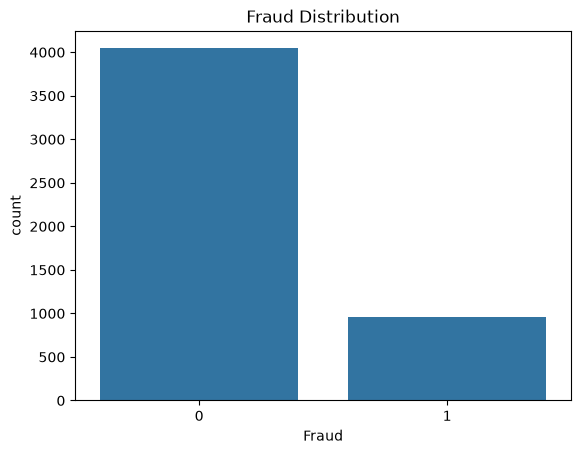

In [4]:
sns.countplot(
    data=df,
    x="Fraud"
)

plt.title("Fraud Distribution")
plt.show()

Cell 5: Correlation Heatmap

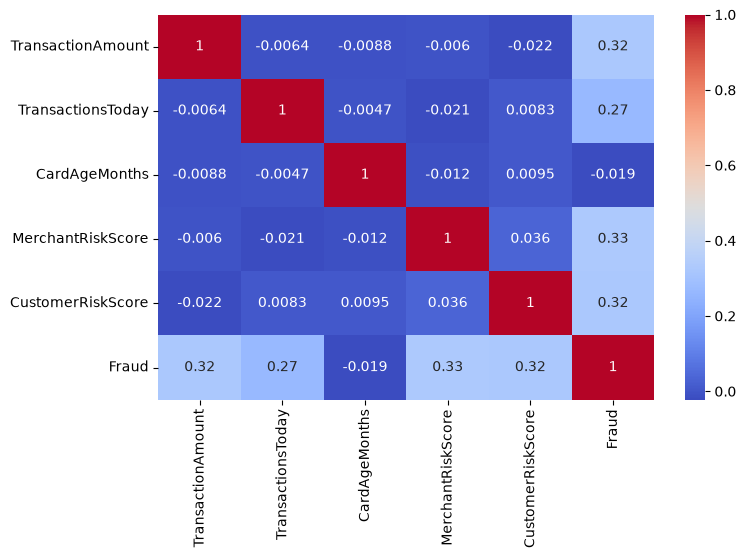

In [5]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Cell 6: Features & Target

In [6]:
X = df.drop("Fraud", axis=1)

y = df["Fraud"]

Cell 7: Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Cell 8: Scaling (Mandatory for SVM)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Cell 9: Train SVM

In [9]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_scaled,
    y_train
)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


Cell 10: Predictions

In [10]:
y_pred = svm.predict(
    X_test_scaled
)

y_prob = svm.predict_proba(
    X_test_scaled
)[:,1]

print(y_pred)
print(y_prob)

[0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 0 0 1 0
 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1
 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0
 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0
 1 0 1 0 1 0 0 0 0 0 0 0 

Cell 11: Evaluation

In [11]:
print("Accuracy :",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall   :",
      recall_score(y_test, y_pred))

print("F1 Score :",
      f1_score(y_test, y_pred))

Accuracy : 0.95
Precision: 0.9028571428571428
Recall   : 0.8272251308900523
F1 Score : 0.8633879781420765


Cell 12: Confusion Matrix

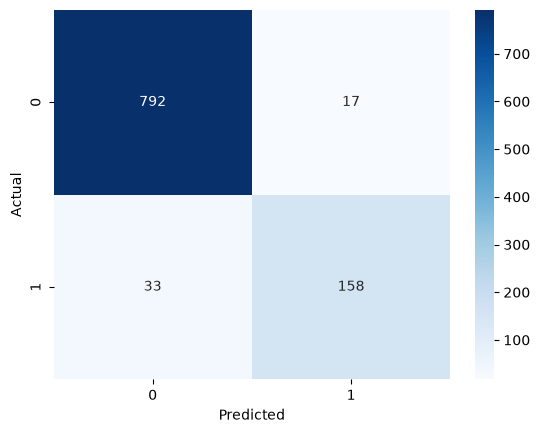

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Cell 13: Classification Report

In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       809
           1       0.90      0.83      0.86       191

    accuracy                           0.95      1000
   macro avg       0.93      0.90      0.92      1000
weighted avg       0.95      0.95      0.95      1000



Cell 14: Hyperparameter Tuning

In [14]:
params = {
    "C":[0.1,1,10],
    "kernel":["linear","rbf"],
    "gamma":["scale","auto"]
}

grid = GridSearchCV(
    SVC(probability=True),
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


Cell 15: Best Model

In [15]:
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       809
           1       0.93      0.88      0.91       191

    accuracy                           0.96      1000
   macro avg       0.95      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



Cell 16: Train vs Test Score

In [16]:
print(
    "Train Score:",
    best_svm.score(
        X_train_scaled,
        y_train
    )
)

print(
    "Test Score:",
    best_svm.score(
        X_test_scaled,
        y_test
    )
)

Train Score: 0.9825
Test Score: 0.965


Cell 17: Predict New Transaction

In [25]:
new_transaction = pd.DataFrame({
    "TransactionAmount": [75000],
    "TransactionsToday": [15],
    "CardAgeMonths": [6],
    "MerchantRiskScore": [9],
    "CustomerRiskScore": [8]
})

new_transaction_scaled = scaler.transform(
    new_transaction
)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 1
Probability: [2.22860117e-06 9.99997771e-01]
